# 🔍 Interpretabilidad — SHAP (final, sobre `src`)

> **Capa final**: usa `ml_hotel_cancellations.utils.interpretability` y el mejor modelo guardado (`models/best_model.pkl`). La versión exploratoria manual (estilo `recursos/`) está en `notebooks/playground/06_interpretabilidad.ipynb`. Glosario: `../docs/glosario.md`.

Un modelo con buen ROC-AUC (aquí **XGBoost**, ≈ 0.9614 en test) acierta mucho, pero por sí solo es una **caja negra**: no explica *por qué* decide lo que decide. En este cuaderno abrimos esa caja reutilizando las utilidades de `src`:

- **SHAP** (`TreeExplainer`, exacto para árboles) — importancia **global** (beeswarm + bar) y explicación **local** (waterfall).
- **Importancia por permutación** — contraste **agnóstico al modelo**.

Comprobamos que el modelo ha aprendido los **mismos patrones** que el análisis exploratorio (EDA), lo que aumenta la confianza en que generaliza por las razones correctas.

## 0. Configuración e imports del contrato `src`

Importamos las funciones de `src` que se usan también en producción: el cargador de datos (`load_and_prepare`), el cargador del mejor modelo (`load_best_model`) y el módulo de interpretabilidad (`interpretability`).

> Importar `src` fija el backend **Agg** de matplotlib (no interactivo, para guardar PNG sin pantalla). Como aquí queremos ver los gráficos en línea, reactivamos el backend *inline* **después** de los imports.

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import shap
from ml_hotel_cancellations import config
from ml_hotel_cancellations.ml.data_loader import load_and_prepare
from ml_hotel_cancellations.ml.predict import load_best_model
from ml_hotel_cancellations.utils import interpretability as interp

# Importar src fija el backend 'Agg'; reactivamos el inline para ver los gráficos.
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt  # re-vincular tras cambiar de backend
%matplotlib inline

print('Versión de SHAP:', shap.__version__)

Versión de SHAP: 0.49.1


## 1. Modelo y datos

Cargamos el `Pipeline` ganador (`models/best_model.pkl`) y la partición train/test **exactamente igual que en producción**. El modelo es un `Pipeline(preprocessor, model)`:

- `preprocessor` — estandariza las numéricas y aplica *one-hot* a las categóricas.
- `model` — el clasificador **XGBoost** (`XGBClassifier`).

SHAP necesita los datos en el espacio del estimador final (matriz preprocesada), por eso más adelante separamos ambos pasos.

In [2]:
modelo = load_best_model()
X_train, X_test, y_train, y_test = load_and_prepare()

print('Pipeline:', ' -> '.join(modelo.named_steps.keys()))
print('Modelo final:', type(modelo.named_steps['model']).__name__)
print('Test:', X_test.shape, '| train:', X_train.shape)

Pipeline: preprocessor -> model
Modelo final: XGBClassifier
Test: (23842, 28) | train: (95368, 28)


In [3]:
# ROC-AUC en test (métrica principal, config.PRIMARY_METRIC).
from sklearn.metrics import roc_auc_score
proba_test = modelo.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba_test)
print(f'ROC-AUC en test: {auc:.4f}')

ROC-AUC en test: 0.9614


## 2. SHAP — ¿qué es? (en lenguaje sencillo)

**SHAP** son las siglas de *SHapley Additive exPlanations*. La idea viene de la **teoría de juegos**: imagina que las variables de una reserva (`lead_time`, `deposit_type`, `country`...) son los *jugadores* de un equipo y la *predicción* es el premio que consiguen. Los **valores de Shapley** reparten ese premio entre los jugadores de forma matemáticamente justa, según cuánto aporta cada uno.

Trasladado a nuestro modelo:

- Cada reserva tiene una predicción (probabilidad de cancelación).
- SHAP la descompone en una **suma de contribuciones**, una por variable.
- Un valor SHAP **positivo** empuja hacia *cancela*; uno **negativo**, hacia *no cancela*. El tamaño indica la fuerza del empujón.

| Nivel | Pregunta que responde | Gráfico |
|---|---|---|
| **Global** | ¿Qué variables manejan al modelo *en conjunto*? | beeswarm, bar |
| **Local** | ¿Por qué predijo *esta* reserva concreta? | waterfall |

Para árboles (XGBoost, Random Forest) usamos `shap.TreeExplainer`, que calcula los valores de Shapley de forma **exacta y rápida** aprovechando la estructura de los árboles.

Calculamos los valores SHAP sobre una **submuestra de ~2000 reservas** (`interp.DEFAULT_SHAP_SAMPLE`): suficiente para una imagen global estable y mucho más rápido que usar las 23 842 del test. Reutilizamos el helper `interp._build_tree_explainer`, que (1) aplica el `preprocessor`, (2) construye el `TreeExplainer` sobre el paso `model` y (3) etiqueta las columnas one-hot. Incluye además un parche para la compatibilidad SHAP/XGBoost.

In [4]:
X_sample = X_test.sample(n=interp.DEFAULT_SHAP_SAMPLE, random_state=config.RANDOM_STATE)
explanation, X_trans, feature_names = interp._build_tree_explainer(modelo, X_sample)
print('Submuestra:', X_sample.shape[0], 'reservas')
print('Valores SHAP:', explanation.values.shape, '(reservas x características one-hot)')
print('Características tras el preprocesado:', len(feature_names))

Submuestra: 2000 reservas
Valores SHAP: (2000, 125) (reservas x características one-hot)
Características tras el preprocesado: 125


## 3. Importancia global: ¿qué variables manejan el modelo?

### 3.1. Barras: importancia media

Cada barra es la **media del valor absoluto de SHAP** de una variable: cuánto mueve la predicción *en promedio*, sin importar la dirección. Es el resumen más directo de *qué pesa más*.

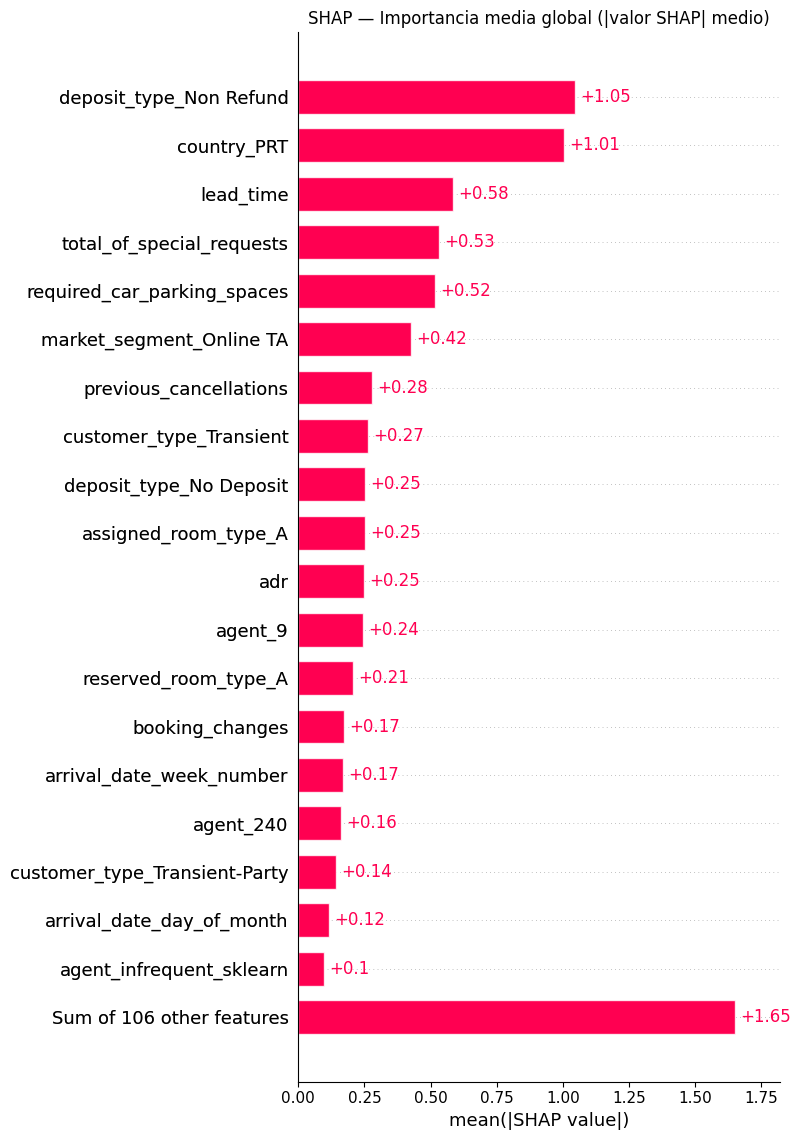

In [5]:
shap.plots.bar(explanation, max_display=20, show=False)
plt.title('SHAP — Importancia media global (|valor SHAP| medio)')
plt.tight_layout(); plt.show()

### 3.2. Beeswarm (enjambre): importancia **y** dirección

El *beeswarm* añade lo que las barras no muestran:

- **Cada punto** es una reserva.
- **Eje X**: su valor SHAP (derecha = empuja hacia *cancela*; izquierda = hacia *no cancela*).
- **Color**: el valor de la variable (rojo = alto, azul = bajo).

Así se lee de un vistazo la *dirección* del efecto: si los puntos rojos de `lead_time` están a la derecha, significa que **más antelación → más cancelación**.

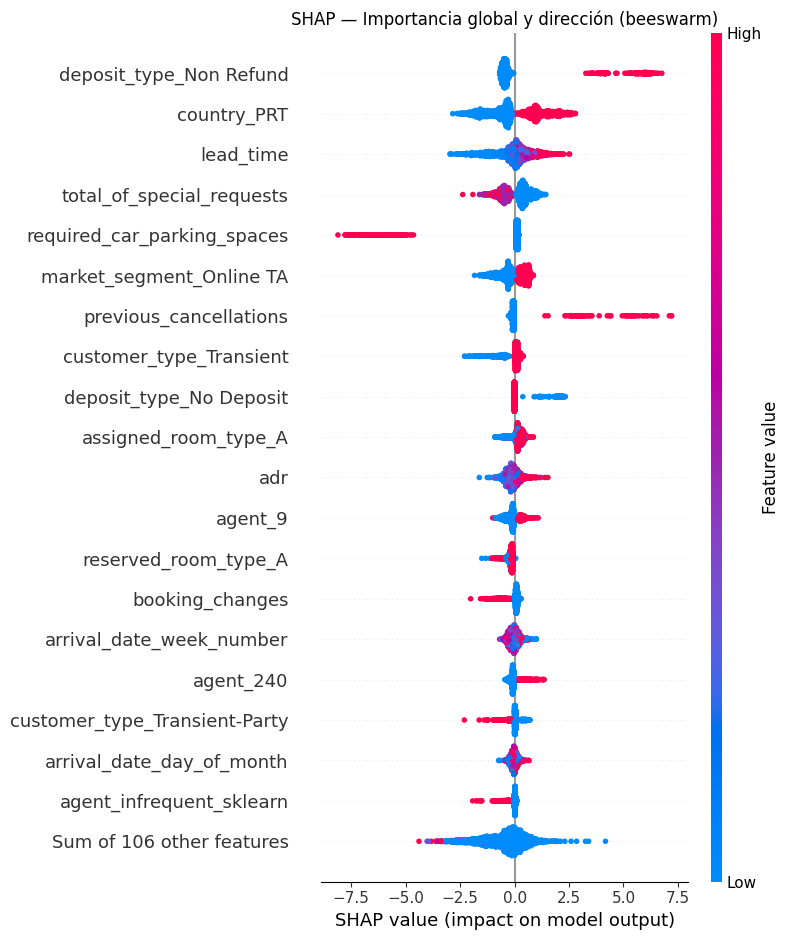

In [6]:
shap.plots.beeswarm(explanation, max_display=20, show=False)
plt.title('SHAP — Importancia global y dirección (beeswarm)')
plt.tight_layout(); plt.show()

### 3.3. Lectura de los gráficos globales

Las variables con más peso (cabecera del ranking) son, de forma muy estable:

- **`deposit_type_Non Refund`**: cuando está activa (depósito no reembolsable), el valor SHAP es fuertemente positivo → empuja hacia *cancela*. Coincide con el EDA, donde este depósito tenía una tasa de cancelación **cercana al 99 %**.
- **`country_PRT`** (Portugal): el país discrimina mucho; las reservas desde Portugal (mercado dominante del dataset) tienden a cancelarse más.
- **`lead_time`** (días de antelación): los valores altos (rojo) caen a la derecha → **a más antelación, más cancelación**, tal como anticipaba el EDA.
- **`total_of_special_requests`** y **`required_car_parking_spaces`**: actúan **al revés**; valores altos (clientes más comprometidos) empujan hacia *no cancela*.
- **`previous_cancellations`**: un historial de cancelaciones previas sube el riesgo.

El modelo ha aprendido **exactamente los patrones del EDA**, lo que refuerza la confianza en que generaliza por las razones correctas y no por artefactos.

## 4. Explicación local: ¿por qué *esta* reserva?

El gráfico de **cascada** (*waterfall*) explica una predicción individual. Parte del **valor base** (`E[f(x)]`, la predicción media del modelo, en *log-odds*) y va sumando/restando la contribución de cada variable hasta llegar a la predicción final `f(x)` de esa reserva. Las barras rojas empujan hacia *cancela* y las azules hacia *no cancela*.

Elegimos automáticamente un caso extremo con el helper `interp.find_examples`: la reserva del test con **mayor** probabilidad estimada de cancelación.

In [7]:
ejemplos = interp.find_examples(modelo, X_test)
i1 = ejemplos['alta_prob']
print(f"Ejemplo (alta prob): idx={i1}  p(cancela)={proba_test[i1]:.3f}  real={y_test.iloc[i1]}")

cols = ['deposit_type', 'lead_time', 'country', 'previous_cancellations',
        'total_of_special_requests', 'market_segment']
X_test.iloc[[i1]][cols].T.rename(columns={X_test.index[i1]: 'Ejemplo'})

Ejemplo (alta prob): idx=2698  p(cancela)=1.000  real=1


,Ejemplo
deposit_type,Non Refund
lead_time,379
country,PRT
previous_cancellations,1
total_of_special_requests,0
market_segment,Groups


### 4.1. Waterfall — reserva que el modelo da por **cancelada**

Una reserva con depósito *Non Refund*, mucha antelación (`lead_time` alto), desde Portugal y sin peticiones especiales: el perfil de riesgo máximo según el EDA. Reutilizamos `interp._build_tree_explainer` sobre esa única fila.

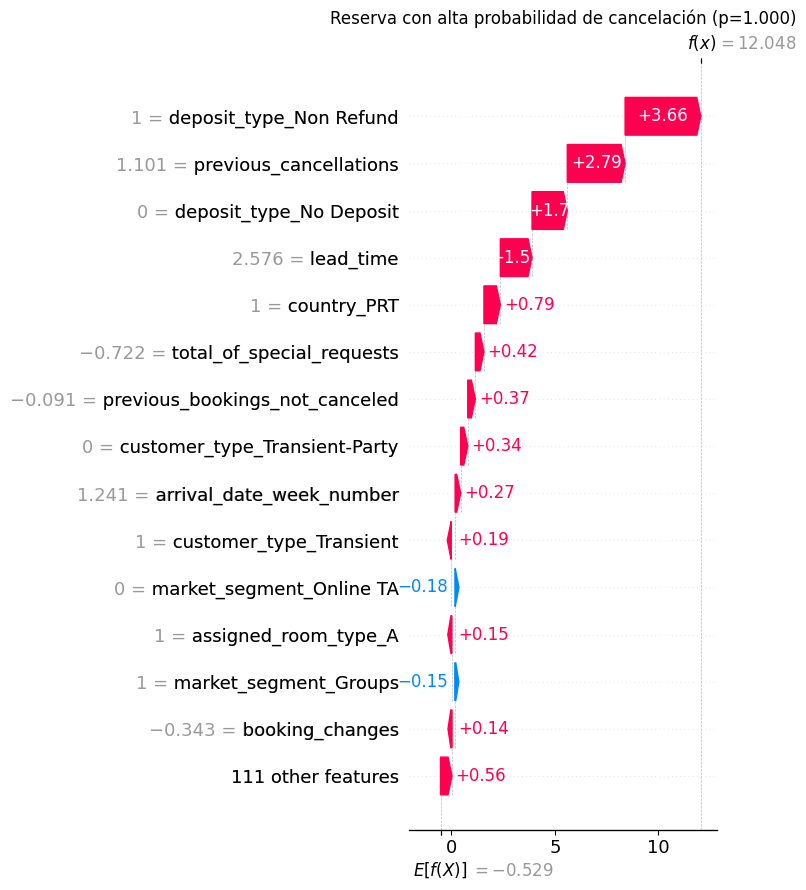

In [8]:
expl1, _, _ = interp._build_tree_explainer(modelo, X_test.iloc[[i1]])
shap.plots.waterfall(expl1[0], max_display=15, show=False)
plt.title(f'Reserva con alta probabilidad de cancelación (p={proba_test[i1]:.3f})')
plt.tight_layout(); plt.show()

## 5. Contraste: importancia por permutación (agnóstica al modelo)

SHAP (`TreeExplainer`) es específico de árboles. Como **contraste independiente** usamos la **importancia por permutación**: barajamos al azar los valores de una variable y medimos cuánto cae el ROC-AUC. Si cae mucho, el modelo dependía de ella. Ventajas: es **agnóstica al modelo** (vale para regresión logística, redes...) y atribuye la importancia a las variables **originales** (no a las columnas one-hot).

Usamos el helper `interp.permutation_importance_report`, que opera sobre el `Pipeline` completo con `scoring=config.PRIMARY_METRIC` (`roc_auc`).

> Para acotar el tiempo, lo calculamos sobre una **submuestra** del test con `n_repeats=5`. El pipeline reproducible (`python -m ml_hotel_cancellations.utils.interpretability`) usa `n_repeats=10` sobre todo el test.

In [9]:
perm_sample = X_test.sample(n=4000, random_state=config.RANDOM_STATE)
y_perm = y_test.loc[perm_sample.index]
tabla_perm, _ = interp.permutation_importance_report(
    modelo, perm_sample, y_perm, n_repeats=5, top_n=15
)
tabla_perm.head(10)

,variable,importancia_media,importancia_std
0,country,0.099248,0.003906
1,deposit_type,0.077891,0.003487
2,lead_time,0.046429,0.002734
3,agent,0.041961,0.001260
4,market_segment,0.039206,0.001993
5,required_car_parking_spaces,0.036405,0.002809
6,total_of_special_requests,0.030077,0.000352
7,customer_type,0.026478,0.002617
8,previous_cancellations,0.023360,0.001580
9,assigned_room_type,0.021342,0.002463


La importancia por permutación **confirma** el ranking de SHAP: `country`, `deposit_type`, `lead_time` y `total_of_special_requests` encabezan ambas listas. Que dos técnicas distintas coincidan refuerza la fiabilidad de las conclusiones.

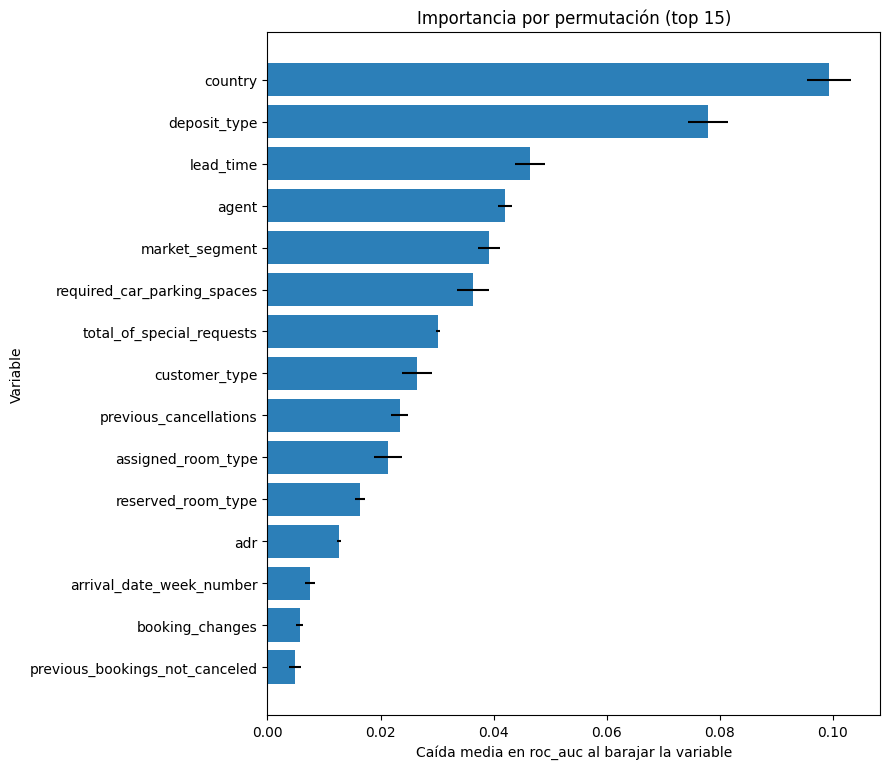

In [10]:
# Gráfico de barras del top de la tabla de permutación.
top = tabla_perm.head(15).iloc[::-1]
plt.figure(figsize=(9, 0.42 * len(top) + 1.5))
plt.barh(top['variable'], top['importancia_media'],
         xerr=top['importancia_std'], color='#2c7fb8')
plt.xlabel(f'Caída media en {config.PRIMARY_METRIC} al barajar la variable')
plt.ylabel('Variable')
plt.title(f'Importancia por permutación (top {len(top)})')
plt.tight_layout(); plt.show()

## 6. Conclusiones y conexión con el EDA

- El mejor modelo (XGBoost) **no es una caja negra opaca**: SHAP descompone cada predicción en contribuciones interpretables.
- Los *drivers* principales coinciden con lo que el EDA señaló como informativo: **`deposit_type='Non Refund'`** (tasa de cancelación ~99 %), **`lead_time`** (más antelación → más cancelación), **`country`** (Portugal como mercado dominante) y **`total_of_special_requests`** (señal de compromiso que reduce el riesgo). El modelo aprendió **señales reales**, no artefactos.
- A nivel **local**, el *waterfall* permite explicar reservas concretas al negocio ("esta reserva se marca como riesgo porque tiene depósito no reembolsable y mucha antelación").
- **SHAP** (específico de árboles) y la **importancia por permutación** (agnóstica) coinciden en el ranking: dos técnicas independientes que se corroboran.
- **Limitaciones**: SHAP se calcula sobre una submuestra por eficiencia; las variables de alta cardinalidad (`country`, `agent`) están agrupadas por el one-hot limitado (`config.MAX_OHE_CATEGORIES`), así que su importancia se reparte entre las categorías más frecuentes; y los valores SHAP del modelo de árboles se expresan en *log-odds*, no en probabilidad directa.

Todos los gráficos se regeneran de forma reproducible con:

```bash
python -m ml_hotel_cancellations.utils.interpretability
```

y se guardan en `outputs/` (`shap_summary_beeswarm.png`, `shap_summary_bar.png`, `shap_waterfall_*.png`, `permutation_importance.png`). A continuación los mostramos como **contraste** si existen en disco.

shap_summary_bar.png


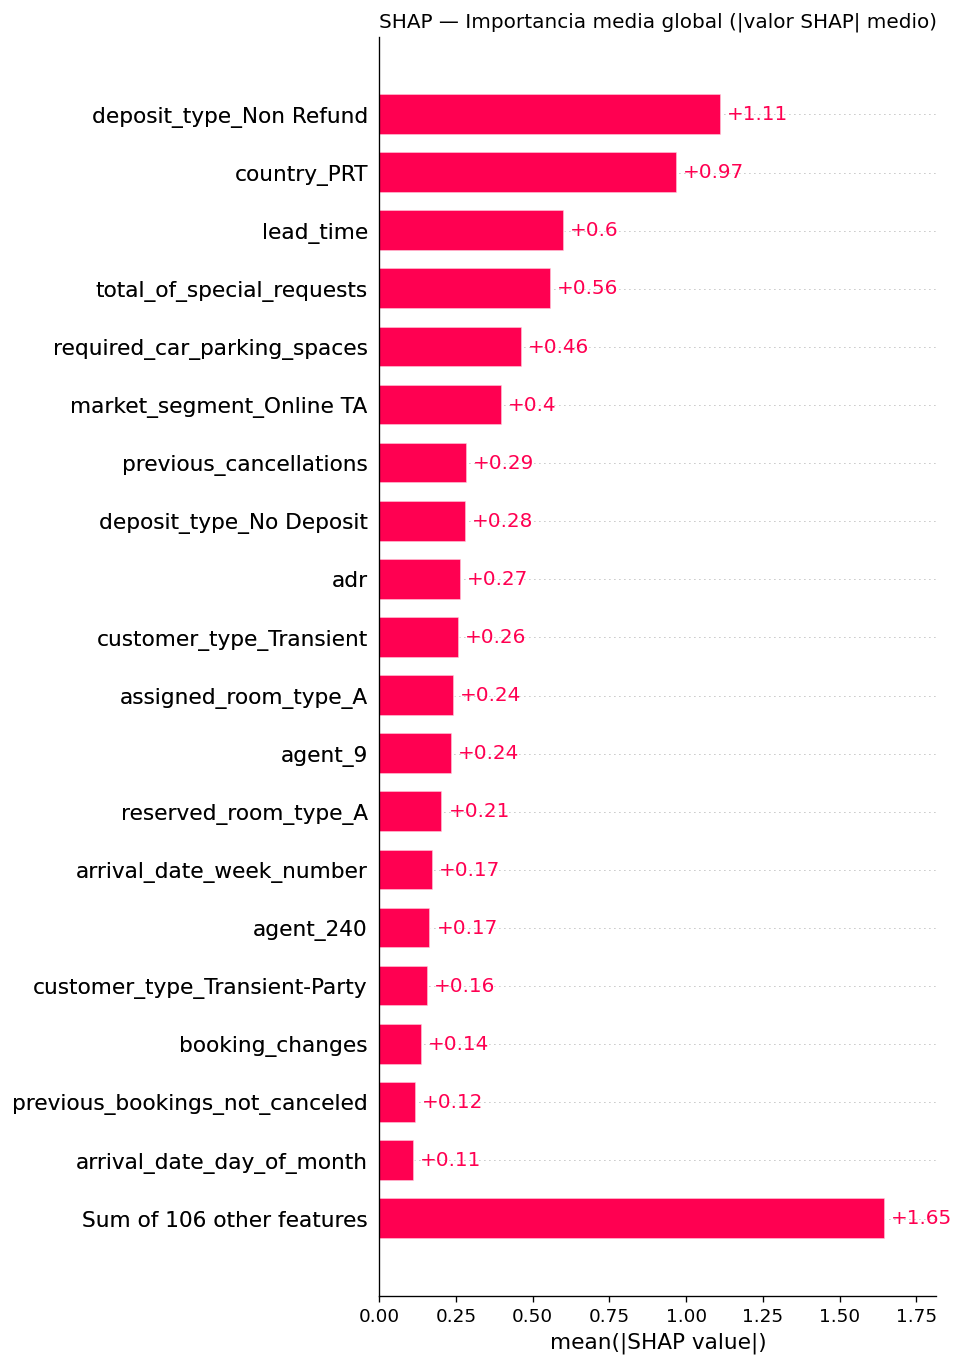

shap_summary_beeswarm.png


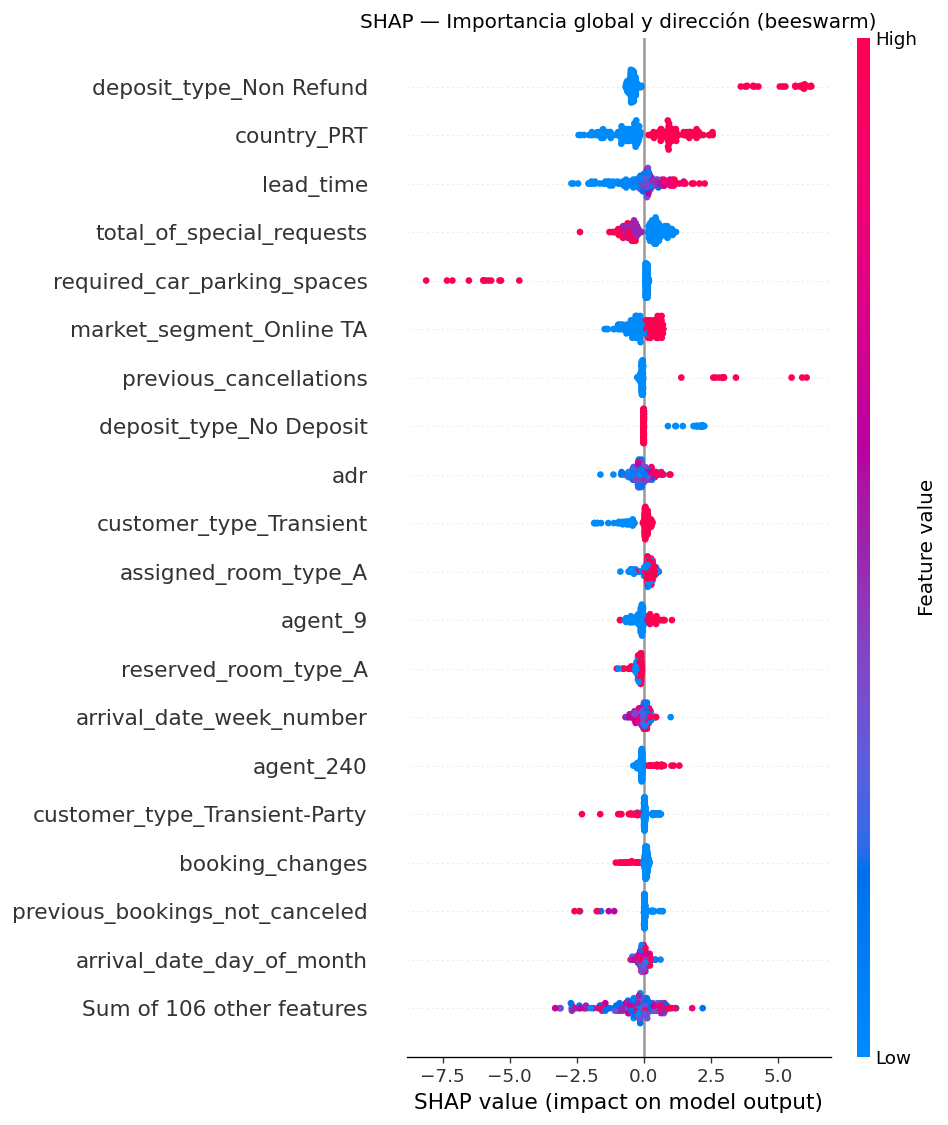

shap_waterfall_ejemplo1.png


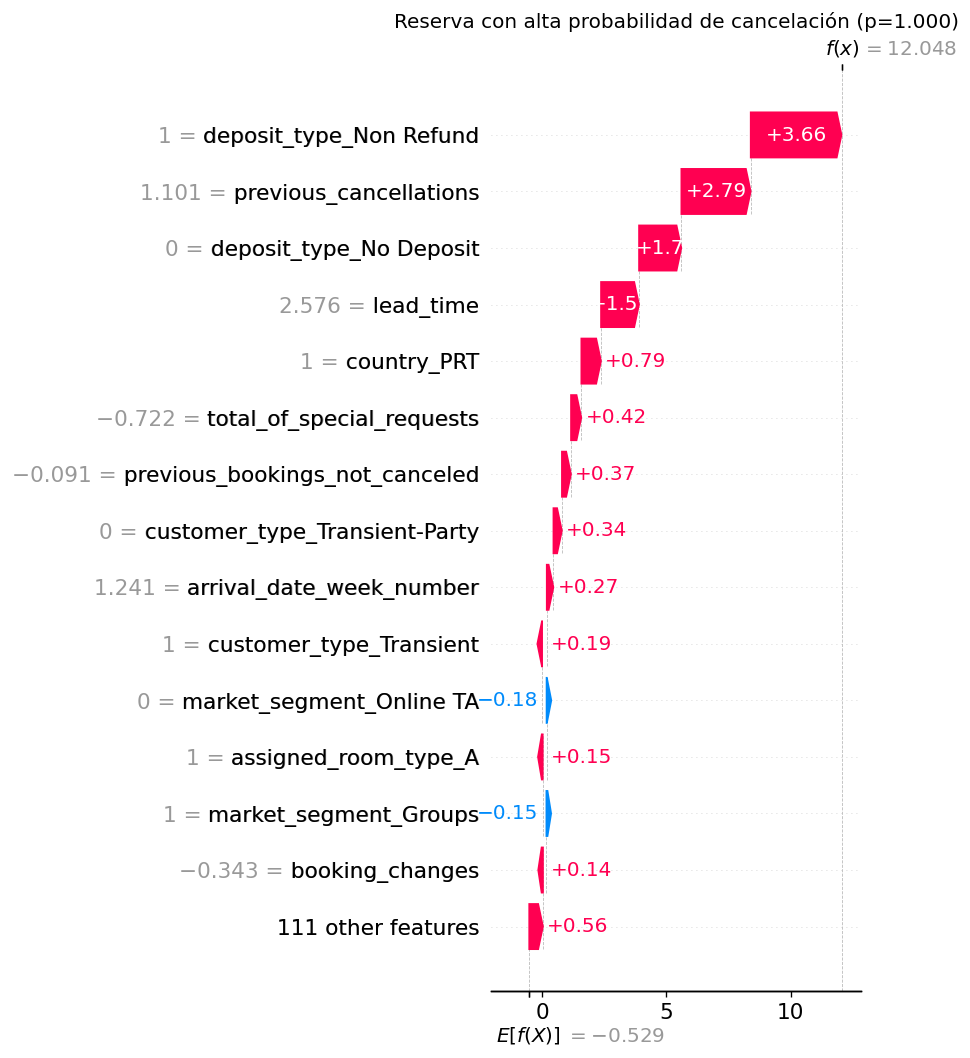

permutation_importance.png


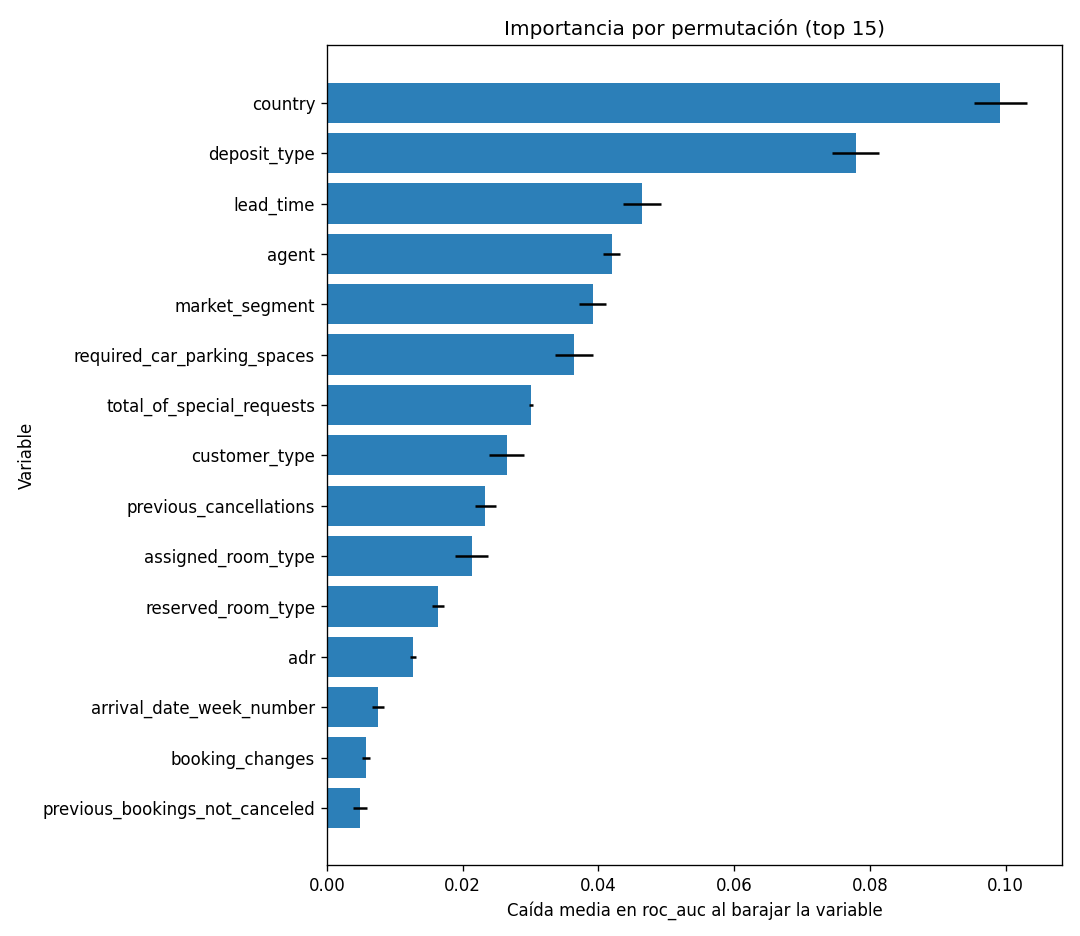

In [11]:
from pathlib import Path
from IPython.display import Image, display

artefactos = [
    'shap_summary_bar.png',
    'shap_summary_beeswarm.png',
    'shap_waterfall_ejemplo1.png',
    'permutation_importance.png',
]
for nombre in artefactos:
    ruta = config.OUTPUTS_DIR / nombre
    if ruta.exists():
        print(nombre)
        display(Image(filename=str(ruta)))
    else:
        print(f'(no encontrado: {ruta})')

Documentación didáctica detallada en [`../docs/interpretabilidad.md`](../docs/interpretabilidad.md). Glosario de términos en [`../docs/glosario.md`](../docs/glosario.md).